## Prepare dataset

In [1]:
DATASET_NAME = "OASIS"
DATA_PATH = "/data/galati/brain_data/OASIS_NEW/OASIS_Train"

#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils, os
import os

def img_path_to_brain_path(img_path):
    brain_path = img_path.replace("_Train", "_Train_BR").replace('.nii.gz', '_bet_mask_join_join.nii.gz')
    if os.path.exists(brain_path):
        return brain_path
    else:
        # Try remove 'join'
        brain_path = img_path.replace("_Train", "_Train_BR").replace('.nii.gz', '_bet_mask.nii.gz')
        if os.path.exists(brain_path):
            return brain_path
        else:
            print(f"Brain mask not found for {img_path}, returning None.")
            return None

def img_path_to_vessel_path(img_path):
    # Convert to GT directory structure
    vessel_path = img_path.replace("_Train", "_Train_GT_ANAIS")
    
    # Get the directory two levels up (removes NIFTI and subject dirs)
    dir_name = os.path.dirname(os.path.dirname(vessel_path))
    # Remove the third to last folder from the path
    parts = dir_name.split(os.sep)
    if len(parts) > 3:
        del parts[-3]
    dir_name = os.sep.join(parts)
    
    # Try vessel_mask_2.nii.gz first, fallback to vessel_mask.nii.gz
    vessel_path = os.path.join(dir_name, "vessel_mask_2.nii.gz") if os.path.exists(os.path.join(dir_name, "vessel_mask_2.nii.gz")) else os.path.join(dir_name, "vessel_mask.nii.gz")
    # Check for AG version first
    ag_vessel_path = vessel_path.replace('.nii.gz', '_AG.nii.gz')
    if os.path.exists(ag_vessel_path):
        vessel_path = ag_vessel_path
    
    # Return path if exists, otherwise None
    if os.path.exists(vessel_path):
        return vessel_path
    else:
        print(f"Vessel mask not found at {vessel_path}, returning None.")
        return None
    
def img_path_to_weight_path(img_path):
    return None



utils.img_path_to_brain_path = img_path_to_brain_path
utils.img_path_to_vessel_path = img_path_to_vessel_path
utils.img_path_to_weight_path = img_path_to_weight_path

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = ".*\_angio.nii.gz$"

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = [
    "sub-OAS30003_ses-d3320_acq-TOF_angio.nii.gz",
    "sub-OAS30007_ses-d1981_acq-TOF_angio.nii.gz",
    "sub-OAS30013_ses-d0102_acq-TOF_angio.nii.gz",
    "sub-OAS30046_ses-d0848_acq-TOF_run-01_angio.nii.gz",
    "sub-OAS30046_ses-d1968_acq-TOF_angio.nii.gz",
    "sub-OAS30061_ses-d0035_acq-TOF_angio.nii.gz",
    "sub-OAS30062_ses-d3469_acq-TOF_angio.nii.gz",
    "sub-OAS30083_ses-d3827_acq-TOF_angio.nii.gz"
]

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = True

#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = False

#this parameter is to specify whether to discard slices which do not contain any portion of the brain or keep them
DISCARD_EXTRA_SLICES = False

### Extract paths

In [2]:
import os, re

from utils import search_nii, extract_paths, load_info_from_checkpoint

In [3]:
if not os.path.isfile(f"info_{DATASET_NAME}.pkl"):
    print("Creating info file...")
    info = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None,
    }
    search_nii(DATA_PATH, info["train"])
else:
    info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

Creating info file...


### Display examples

In [4]:
import random

from utils import print_bold, load_and_display_middle_slice

In [5]:
info["train"].paths

['/data/galati/brain_data/OASIS_NEW/OASIS_Train/OAS30001/OAS30001_MR_d2430/anat1/NIFTI/sub-OAS30001_ses-d2430_acq-TOF_angio.nii.gz',
 '/data/galati/brain_data/OASIS_NEW/OASIS_Train/OAS30002/OAS30002_MR_d2340/anat1/NIFTI/sub-OAS30002_ses-d2340_acq-TOF_angio.nii.gz',
 '/data/galati/brain_data/OASIS_NEW/OASIS_Train/OAS30003/OAS30003_MR_d3731/anat1/NIFTI/sub-OAS30003_ses-d3731_acq-TOF_angio.nii.gz',
 '/data/galati/brain_data/OASIS_NEW/OASIS_Train/OAS30004/OAS30004_MR_d3457/anat1/NIFTI/sub-OAS30004_ses-d3457_acq-TOF_angio.nii.gz',
 '/data/galati/brain_data/OASIS_NEW/OASIS_Train/OAS30005/OAS30005_MR_d3453/anat1/NIFTI/sub-OAS30005_ses-d3453_acq-TOF_angio.nii.gz',
 '/data/galati/brain_data/OASIS_NEW/OASIS_Train/OAS30006/OAS30006_MR_d2342/anat1/NIFTI/sub-OAS30006_ses-d2342_acq-TOF_angio.nii.gz',
 '/data/galati/brain_data/OASIS_NEW/OASIS_Train/OAS30008/OAS30008_MR_d1313/anat1/NIFTI/sub-OAS30008_ses-d1313_acq-TOF_angio.nii.gz',
 '/data/galati/brain_data/OASIS_NEW/OASIS_Train/OAS30008/OAS30008_MR_

[Example 01]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 576 768 232   1   0   0   0]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.29947916 0.29947916 0.59999084 0.025      0.
 0.         0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'removed'
aux_file        : b'OAS30071_MR_d0055'
qform_code      : scanner
sform_code      : scanner
quatern_b       : 1.7433789e-25
quatern_c       : 1.7e-15
quatern_d       : -1.02551696e-10


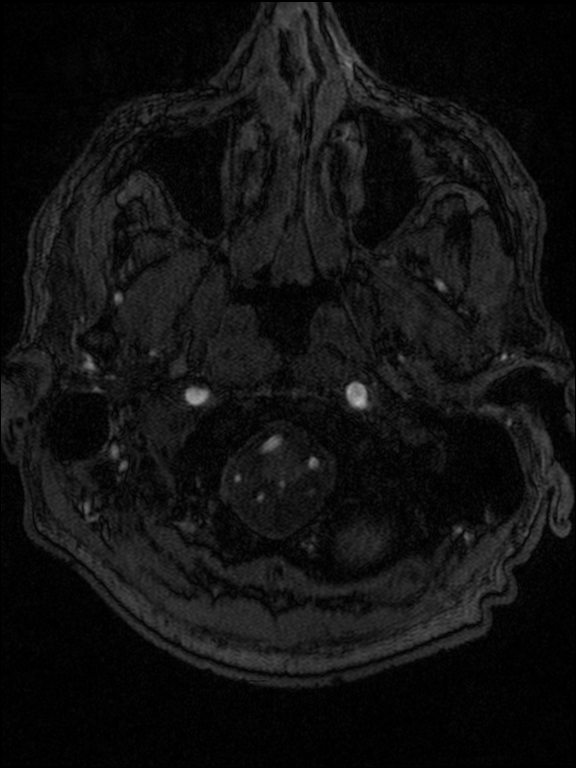

[Example 02]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 576 768 232   1   0   0   0]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.29947916 0.29947916 0.5999985  0.023      0.
 0.         0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'removed'
aux_file        : b'OAS30009_MR_d2457'
qform_code      : scanner
sform_code      : scanner
quatern_b       : 1.7433788e-25
quatern_c       : 1.7e-15
quatern_d       : -1.02551696e-10


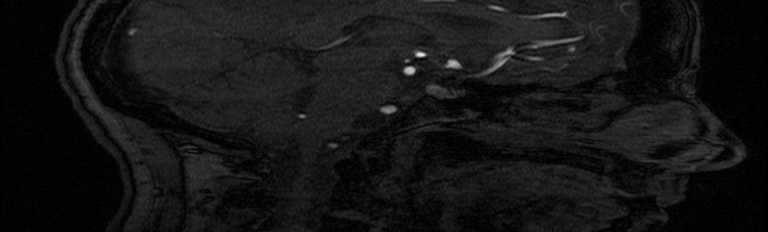

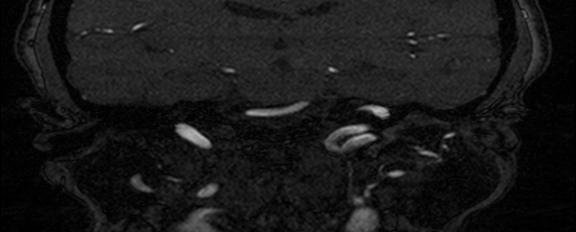

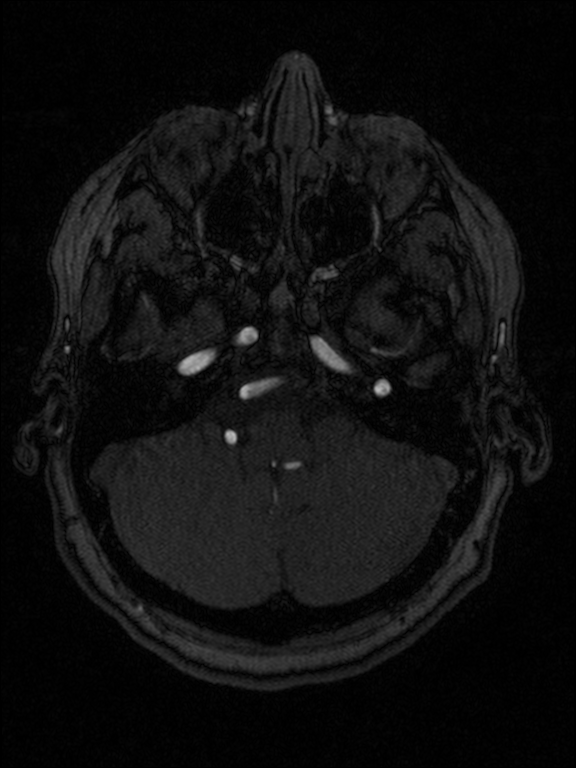

In [6]:
print_bold("[Example 01]")
random.seed(0)
load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)

print_bold("[Example 02]")
random.seed(1)
load_and_display_middle_slice(random.choice(info["train"].paths), axis=[0,1,2], display_header=True)

### Split train/val/test

In [7]:
from utils import is_medical_volume

In total, there are

In [8]:
IMGs = sum([
    info["train"].paths,
    info["val"].paths if info["val"] is not None else [],
    info["test"].paths if info["test"] is not None else []
], [])

len(IMGs)

35

volumes. First, we discard the outliers:

In [9]:
IMGs = [img_path for img_path in IMGs if os.path.basename(img_path) not in OUTLIERs]

len(IMGs)

35

We have vessel annotations for

In [10]:
HAVE_VESSELs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
]

len(HAVE_VESSELs)

35

of them. With a chosen ratio of 70-15-15, we select

In [11]:
COUNT_TEST = 7
COUNT_TEST

7

images to be part of the validation/testing set.

In case brain masks are available, we collect them too.

In [12]:
HAVE_BRAINs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_brain_path(img_path))
]

len(HAVE_BRAINs)

# Print all the paths in HAVE_BRAINs
for path in HAVE_BRAINs:
    print(img_path_to_brain_path(path))


/data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30001/OAS30001_MR_d2430/anat1/NIFTI/sub-OAS30001_ses-d2430_acq-TOF_angio_bet_mask_join_join.nii.gz
/data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30002/OAS30002_MR_d2340/anat1/NIFTI/sub-OAS30002_ses-d2340_acq-TOF_angio_bet_mask_join_join.nii.gz
/data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30003/OAS30003_MR_d3731/anat1/NIFTI/sub-OAS30003_ses-d3731_acq-TOF_angio_bet_mask_join_join.nii.gz
/data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30004/OAS30004_MR_d3457/anat1/NIFTI/sub-OAS30004_ses-d3457_acq-TOF_angio_bet_mask_join_join.nii.gz
/data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30005/OAS30005_MR_d3453/anat1/NIFTI/sub-OAS30005_ses-d3453_acq-TOF_angio_bet_mask_join_join.nii.gz
/data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30006/OAS30006_MR_d2342/anat1/NIFTI/sub-OAS30006_ses-d2342_acq-TOF_angio_bet_mask_join_join.nii.gz
/data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30008/OAS30008_MR_d1313/anat1/NIFTI/sub-OA

In [13]:
import nibabel as nib
import numpy as np

for img in IMGs:
    brain_path = img_path_to_brain_path(img)
    vessel_path = img_path_to_vessel_path(img)
    assert brain_path is not None and vessel_path is not None, f"Both brain and vessel masks are None for {img}."
    
    # Create the output path (assuming brain_path)
    base_path = brain_path
    join_path = base_path.replace('.nii', '_join_join.nii')
    
    if os.path.exists(join_path) or '_join_join.nii.gz' in brain_path:
        print(f"Join mask already exists: {join_path}, skipping.")
        continue
    # Load the original image to get the affine
    img_nii = nib.load(img)
    affine = img_nii.affine
    
    # Initialize join_data with zeros
    join_data = np.zeros(img_nii.shape, dtype=np.uint8)
    
    # Load and combine brain mask if available
    if brain_path is not None:
        brain_nii = nib.load(brain_path)
        brain_data = brain_nii.get_fdata().astype(bool)
        join_data = join_data | brain_data
    
    # Load and combine vessel mask if available
    if vessel_path is not None:
        vessel_nii = nib.load(vessel_path)
        vessel_data = vessel_nii.get_fdata().astype(bool)
        join_data = join_data | vessel_data
    
    # Create the join mask NIfTI image
    join_nii = nib.Nifti1Image(join_data.astype(np.uint8), affine)
        
    # Save the join mask
    nib.save(join_nii, join_path)
    print(f"Saved join mask: {join_path}")
    

Join mask already exists: /data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30001/OAS30001_MR_d2430/anat1/NIFTI/sub-OAS30001_ses-d2430_acq-TOF_angio_bet_mask_join_join_join_join.nii.gz, skipping.
Join mask already exists: /data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30002/OAS30002_MR_d2340/anat1/NIFTI/sub-OAS30002_ses-d2340_acq-TOF_angio_bet_mask_join_join_join_join.nii.gz, skipping.
Join mask already exists: /data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30003/OAS30003_MR_d3731/anat1/NIFTI/sub-OAS30003_ses-d3731_acq-TOF_angio_bet_mask_join_join_join_join.nii.gz, skipping.
Join mask already exists: /data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30004/OAS30004_MR_d3457/anat1/NIFTI/sub-OAS30004_ses-d3457_acq-TOF_angio_bet_mask_join_join_join_join.nii.gz, skipping.
Join mask already exists: /data/galati/brain_data/OASIS_NEW/OASIS_Train_BR/OAS30005/OAS30005_MR_d3453/anat1/NIFTI/sub-OAS30005_ses-d3453_acq-TOF_angio_bet_mask_join_join_join_join.nii.gz, skipping.
Join mask 

Finally, we randomly split our dataset. 

### VAL - TEST IMAGES

In [14]:
IMGs_basename = [os.path.basename(img_path) for img_path in IMGs]

In [15]:
DATA_PATH_COMPLETE = "/data/galati/brain_data/OASIS_NEW/OASIS_Test_Val"

#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils, os

def img_path_to_brain_path_COMPLETE(img_path):
    out_path = img_path.replace("/OASIS_NEW/OASIS_Test_Val/", "/OASIS_NEW/OASIS_Test_Val_BR/")
    
    # Get the directory two levels up (removes NIFTI and subject dirs)
    dir_name = os.path.dirname(os.path.dirname(out_path))
    # Remove the third to last folder from the path
    parts = dir_name.split(os.sep)
    if len(parts) > 3:
        del parts[-3]
    dir_name = os.sep.join(parts)
    # Try vessel_mask_2.nii.gz first, fallback to vessel_mask.nii.gz
    out_path = os.path.join(dir_name, "mask_join_join.nii.gz") 
    return out_path

def img_path_to_vessel_path_COMPLETE(img_path):
    out_path = img_path.replace(".nii.gz", "_GT.nii.gz")
    return out_path
def img_path_to_weight_path(img_path):
    return None

utils.img_path_to_brain_path = img_path_to_brain_path_COMPLETE
utils.img_path_to_vessel_path = img_path_to_vessel_path_COMPLETE
utils.img_path_to_weight_path = img_path_to_weight_path

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = ".*\_angio.nii.gz$"

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = [
    "sub-OAS30003_ses-d3320_acq-TOF_angio.nii.gz",
    "sub-OAS30007_ses-d1981_acq-TOF_angio.nii.gz",
    "sub-OAS30013_ses-d0102_acq-TOF_angio.nii.gz",
    "sub-OAS30046_ses-d0848_acq-TOF_run-01_angio.nii.gz",
    "sub-OAS30046_ses-d1968_acq-TOF_angio.nii.gz",
    "sub-OAS30061_ses-d0035_acq-TOF_angio.nii.gz",
    "sub-OAS30062_ses-d3469_acq-TOF_angio.nii.gz",
    "sub-OAS30083_ses-d3827_acq-TOF_angio.nii.gz"
]

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = True

#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = False

#this parameter is to specify whether to discard slices which do not contain any portion of the brain or keep them
DISCARD_EXTRA_SLICES = False

if not os.path.isfile(f"info_{DATASET_NAME}_COMPLETE.pkl"):
    print("Creating info file...")
    info_COMPLETE = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None,
    }
    search_nii(DATA_PATH_COMPLETE, info_COMPLETE["train"])
else:
    info_COMPLETE = load_info_from_checkpoint(f"info_{DATASET_NAME}_COMPLETE.pkl")

Creating info file...
Path /data/galati/brain_data/OASIS_NEW/OASIS_Test_Val/OAS30003/OAS30003_MR_d2682/anat5/NIFTI/sub-OAS30003_ses-d2682_acq-TOF_run-01_angio_GT.nii.gz does not match the rule .*\_angio.nii.gz$
Path /data/galati/brain_data/OASIS_NEW/OASIS_Test_Val/OAS30003/OAS30003_MR_d2682/anat5/NIFTI_GT/sub-OAS30003_ses-d2682_acq-TOF_run-01_angio_GT.nii.gz does not match the rule .*\_angio.nii.gz$
Path /data/galati/brain_data/OASIS_NEW/OASIS_Test_Val/OAS30005/OAS30005_MR_d2384/anat1/NIFTI/sub-OAS30005_ses-d2384_acq-TOF_angio_GT.nii.gz does not match the rule .*\_angio.nii.gz$
Path /data/galati/brain_data/OASIS_NEW/OASIS_Test_Val/OAS30005/OAS30005_MR_d2384/anat1/NIFTI_GT/sub-OAS30005_ses-d2384_acq-TOF_angio_GT.nii.gz does not match the rule .*\_angio.nii.gz$
Path /data/galati/brain_data/OASIS_NEW/OASIS_Test_Val/OAS30007/OAS30007_MR_d1636/anat1/NIFTI/sub-OAS30007_ses-d1636_acq-TOF_angio_GT.nii.gz does not match the rule .*\_angio.nii.gz$
Path /data/galati/brain_data/OASIS_NEW/OASIS_Tes

In [16]:
IMGs_COMPLETE = sum([
    info_COMPLETE["train"].paths,
    info_COMPLETE["val"].paths if info_COMPLETE["val"] is not None else [],
    info_COMPLETE["test"].paths if info_COMPLETE["test"] is not None else []
], [])

len(IMGs_COMPLETE)

14

In [17]:
IMGs_COMPLETE = [img_path for img_path in IMGs_COMPLETE if os.path.basename(img_path) not in OUTLIERs]
IMGs_COMPLETE = [img_path for img_path in IMGs_COMPLETE if os.path.basename(img_path) not in IMGs_basename]

len(IMGs_COMPLETE)

14

In [18]:
HAVE_VESSELs_COMPLETE = [
    img_path for img_path in IMGs_COMPLETE if is_medical_volume(img_path_to_vessel_path_COMPLETE(img_path))
]

len(HAVE_VESSELs_COMPLETE)

14

In [19]:
HAVE_BRAINs_COMPLETE = [
    img_path for img_path in IMGs_COMPLETE if is_medical_volume(img_path_to_brain_path_COMPLETE(img_path))
]

len(HAVE_BRAINs_COMPLETE)


14

In [20]:
for img_c in IMGs_COMPLETE:
    if not is_medical_volume(img_path_to_brain_path_COMPLETE(img_c)):
        continue
    if not is_medical_volume(img_path_to_vessel_path_COMPLETE(img_c)):
        continue
    continue

    brain_path = img_path_to_brain_path_COMPLETE(img_c)
    vessel_path = img_path_to_vessel_path_COMPLETE(img_c)
    assert os.path.exists(brain_path), f"Brain mask not found at {brain_path}."
    assert os.path.exists(vessel_path), f"Vessel mask not found at {vessel_path}."
    
    # Create the output path (assuming brain_path)
    base_path = brain_path
    join_path = base_path.replace('.nii', '_join_join.nii')
    
    # Load the original image to get the affine
    print(f"Processing image: {img_c}")
    img_nii = nib.load(img_c)
    affine = img_nii.affine
    # Initialize join_data with zeros
    join_data = np.zeros(img_nii.shape, dtype=np.uint8)
    # Load and combine brain mask if available
    if brain_path is not None:
        print(f"Loading brain mask from: {brain_path}")
        brain_nii = nib.load(brain_path)
        brain_data = brain_nii.get_fdata().astype(bool)
        join_data = join_data | brain_data
    # Load and combine vessel mask if available
    if vessel_path is not None:
        print(f"Loading vessel mask from: {vessel_path}")
        vessel_nii = nib.load(vessel_path)
        vessel_data = vessel_nii.get_fdata().astype(bool)
        join_data = join_data | vessel_data
        
    # Create the join mask NIfTI image
    join_nii = nib.Nifti1Image(join_data.astype(np.uint8), affine)
    # Save the join mask
    nib.save(join_nii, join_path)
    print(f"Saved join mask: {join_path}")
    
    # Copy the original image and the vessel mask and the join mask to a new directory
    img_c_new = img_c.replace("/OASIS/","/OASIS_NEW/OASIS_Test_Val/")
    vessel_path_new = vessel_path.replace("/OASIS_GT/","/OASIS_NEW/OASIS_Test_Val_GT/")
    join_path_new = join_path.replace("/OASIS_GT/","/OASIS_NEW/OASIS_Test_Val_BR/")
    
    if os.path.exists(img_c_new) and os.path.exists(vessel_path_new) and os.path.exists(join_path_new):
        print(f"Files already exist: {img_c_new}")
        #assert os.path.exists(vessel_path_new), f"Vessel mask path does not match: {vessel_path_new}"
        #assert os.path.exists(join_path_new), f"Join mask path does not match: {join_path_new}"
        continue
    
    os.makedirs(os.path.dirname(img_c_new), exist_ok=True)
    os.makedirs(os.path.dirname(vessel_path_new), exist_ok=True)
    os.makedirs(os.path.dirname(join_path_new), exist_ok=True)
    
    nib.save(nib.load(img_c), img_c_new)
    
    if os.path.exists(vessel_path):
        print(f"Saving vessel mask from {vessel_path} to {vessel_path_new}")
        nib.save(nib.load(vessel_path), vessel_path_new)
    if os.path.exists(join_path):
        print(f"Saving join mask from {join_path} to {join_path_new}")
        nib.save(nib.load(join_path), join_path_new)
    

In [ ]:
random.seed(0)

VAL_IMGs = random.sample(sorted(HAVE_VESSELs_COMPLETE), COUNT_TEST)

print("val: ", [os.path.basename(img) for img in VAL_IMGs])

random.seed(1)

TEST_IMGs = random.sample(sorted([img for img in HAVE_VESSELs_COMPLETE if img not in VAL_IMGs]), COUNT_TEST)

print("test: ", [os.path.basename(img) for img in TEST_IMGs])

TRAIN_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if img not in VAL_IMGs and img not in TEST_IMGs]

print("train: ", [os.path.basename(img) for img in TRAIN_IMGs])


val:  ['sub-OAS30080_ses-d1318_acq-TOF_angio.nii.gz', 'sub-OAS30043_ses-d0145_acq-TOF_run-01_angio.nii.gz', 'sub-OAS30074_ses-d2812_acq-TOF_angio.nii.gz', 'sub-OAS30003_ses-d2682_acq-TOF_run-01_angio.nii.gz', 'sub-OAS30026_ses-d0696_acq-TOF_angio.nii.gz', 'sub-OAS30044_ses-d1319_acq-TOF_angio.nii.gz', 'sub-OAS30044_ses-d0061_acq-TOF_angio.nii.gz']
test:  ['sub-OAS30007_ses-d1636_acq-TOF_angio.nii.gz', 'sub-OAS30052_ses-d2737_acq-TOF_angio.nii.gz', 'sub-OAS30005_ses-d2384_acq-TOF_angio.nii.gz', 'sub-OAS30007_ses-d2722_acq-TOF_angio.nii.gz', 'sub-OAS30057_ses-d0075_acq-TOF_angio.nii.gz', 'sub-OAS30071_ses-d0018_acq-TOF_angio.nii.gz', 'sub-OAS30028_ses-d1847_acq-TOF_angio.nii.gz']
train:  ['sub-OAS30001_ses-d2430_acq-TOF_angio.nii.gz', 'sub-OAS30002_ses-d2340_acq-TOF_angio.nii.gz', 'sub-OAS30003_ses-d3731_acq-TOF_angio.nii.gz', 'sub-OAS30004_ses-d3457_acq-TOF_angio.nii.gz', 'sub-OAS30005_ses-d3453_acq-TOF_angio.nii.gz', 'sub-OAS30006_ses-d2342_acq-TOF_angio.nii.gz', 'sub-OAS30008_ses-d131

In [23]:
# Assert exclusivity
val_set = set(VAL_IMGs)
test_set = set(TEST_IMGs)
train_set = set(TRAIN_IMGs)

assert len(val_set & test_set) == 0, "Validation and test sets overlap"
assert len(val_set & train_set) == 0, "Validation and train sets overlap"
assert len(test_set & train_set) == 0, "Test and train sets overlap"

print("All sets are mutually exclusive ✓")



All sets are mutually exclusive ✓


In [24]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Extract spacings and shapes

In [25]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [26]:
from utils import extract_info_and_masks, loop_nii, display_info, get_target_spacing

In [27]:
info = {
    "train": extract_info_and_masks(path_rule=PATH_RULE),
    "val": extract_info_and_masks(path_rule=PATH_RULE),
    "test": extract_info_and_masks(path_rule=PATH_RULE),
}

loop_nii(TRAIN_IMGs, info["train"])
loop_nii(VAL_IMGs, info["val"])
loop_nii(TEST_IMGs, info["test"])

In [28]:
display_info(info["train"], info["val"])

,#volumes,#slices,spacing median,spacing range,shape median,shape range
TRAIN,35,8056,[000.30 000.30 000.60],[000.30 000.30 000.60] - [000.30 000.30 000.60],[576.00 730.00 232.00],[502.00 677.00 168.00] - [576.00 768.00 232.00]
VAL,7,1646,[000.30 000.30 000.60],[000.30 000.30 000.60] - [000.30 000.30 000.60],[576.00 711.00 232.00],[554.00 694.00 232.00] - [576.00 768.00 254.00]


In [29]:
SPACING = get_target_spacing(
    info["train"].spacings + info["val"].spacings,
    info["train"].shapesAfterCropping() + info["val"].shapesAfterCropping()
)

SPACING

array([0.33691405, 0.44921874, 0.59999847])

In [30]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Crop, Metadata, Resize, Empty Slices Removal, Standardization

In [31]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [32]:
import os

from utils import print_bold, preprocessing_loop

In [33]:
from pathlib import Path


OUT_DIR = "/data/falcetta/A2V_experiments/OASIS_preprocessed_NEW2025"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

In [34]:
print_bold("Training")
preprocessing_loop(
    info["train"],
    os.path.join(OUT_DIR,"numpy", "train"),
    target_spacing=SPACING
)

print_bold("Validation")
preprocessing_loop(
    info["val"],
    os.path.join(OUT_DIR, "numpy", "val"),
    target_spacing=SPACING
)

print_bold("Testing")
preprocessing_loop(
    info["test"],
    os.path.join(OUT_DIR,"numpy", "test"),
    target_spacing=SPACING
)

Training


  0%|          | 0/35 [00:00<?, ?it/s]

(576, 768, 232)
Target spacing: [0.33691405 0.44921874 0.59999847]
Current spacing: [0.29947916 0.29947916 0.5999985 ]
New shape: [512 483 232]
Resized shape: (512, 483, 232)
PASSED New shape: [512, 512]
New shape: [512 512 232]
Resized shape: (512, 512, 232)


  3%|▎         | 1/35 [00:56<32:00, 56.47s/it]

Slices processed: 232
(576, 768, 232)
Target spacing: [0.33691405 0.44921874 0.59999847]
Current spacing: [0.29947916 0.29947916 0.6000004 ]
New shape: [512 501 232]
Resized shape: (512, 501, 232)
PASSED New shape: [512, 512]
New shape: [512 512 232]
Resized shape: (512, 512, 232)


...

Slices processed: 696
(576, 768, 232)
Target spacing: [0.33691405 0.44921874 0.59999847]
Current spacing: [0.29947916 0.29947916 0.5999985 ]
New shape: [512 481 232]
Resized shape: (512, 481, 232)
PASSED New shape: [512, 512]
New shape: [512 512 232]
Resized shape: (512, 512, 232)


 11%|█▏        | 4/35 [03:48<29:32, 57.16s/it]

Slices processed: 928
(576, 768, 232)
Target spacing: [0.33691405 0.44921874 0.59999847]
Current spacing: [0.29947916 0.29947916 0.5999985 ]
New shape: [512 463 232]
Resized shape: (512, 463, 232)
PASSED New shape: [512, 512]
New shape: [512 512 232]
Resized shape: (512, 512, 232)


 11%|█▏        | 4/35 [04:42<36:26, 70.52s/it]


OSError: [Errno 28] No space left on device

In [ ]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Outliers removal and slices extraction

In [ ]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [ ]:
import os

from utils import print_bold, extraction_loop, display_slice

In [ ]:
print_bold("Training")
extraction_loop(
    info["train"],
    os.path.join(OUT_DIR,"slices", "train")
)

print_bold("Validation")
extraction_loop(
    info["val"],
    os.path.join(OUT_DIR,"slices", "val")
)

print_bold("Testing")
extraction_loop(
    info["test"],
    os.path.join(OUT_DIR,"slices", "test")
)

In [ ]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Intensity values analysis

In [ ]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [ ]:
import numpy as np

from utils import intensity_loop, display_intensity
from utils import get_percentile, display_clipped_slice

In [ ]:
print_bold("Training")
intensity_loop(
    info["train"],
    min_value=min(info["train"].min_values + info["val"].min_values),
    max_value=max(info["train"].max_values + info["val"].max_values)
)
display_intensity(info["train"])

print_bold("Validation")
intensity_loop(
    info["val"],
    min_value=min(info["train"].min_values + info["val"].min_values),
    max_value=max(info["train"].max_values + info["val"].max_values)
)
display_intensity(info["val"])

In [ ]:
MIN_VALUE = get_percentile(
    info["train"].bins,
    info["train"].intensity_count + info["val"].intensity_count,
    0.1
)
MAX_VALUE = get_percentile(
    info["train"].bins,
    info["train"].intensity_count + info["val"].intensity_count,
    99.9
)

In [ ]:
min_values_idx = np.argmin(
    info["train"].min_values + info["val"].min_values
)
DARK = (info["train"].preprocessed_paths + info["val"].preprocessed_paths)[min_values_idx]
DARK = DARK.replace("numpy/", "slices/").replace(".npy", "_slice{:03d}.npy").format(100)
display_clipped_slice(DARK, MIN_VALUE, MAX_VALUE)

max_values_idx = np.argmax(
    info["train"].max_values + info["val"].max_values
)
BRIGHT = (info["train"].preprocessed_paths + info["val"].preprocessed_paths)[max_values_idx]
BRIGHT = BRIGHT.replace("numpy/", "slices/").replace(".npy", "_slice{:03d}.npy").format(100)
display_clipped_slice(BRIGHT, MIN_VALUE, MAX_VALUE)

In [ ]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Normalization, Padding & Cropping, One-Hot Encoding

In [ ]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [ ]:
import numpy as np

from utils import display_slice, normalization_loop

In [ ]:
print_bold("Training")
normalization_loop(info["train"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/train", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

print_bold("Validation")
normalization_loop(info["val"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/val", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

print_bold("Testing")
normalization_loop(info["test"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/test", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

In [ ]:
np.save(f"{OUT_DIR}/preprocess_map_{DATASET_NAME}.npy", {
    "train": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/train")),
    "val": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/val")),
    "test": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/test")),
})

In [ ]:
import os
os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/train")

In [ ]:
import numpy as np

img_example = np.load(
    f"{OUT_DIR}/preprocess_{DATASET_NAME}/train/sub-OAS30066_ses-d2006_acq-TOF_angio_slice130.npy", allow_pickle=True
).item()

img_example, msk_example = img_example["data"][:,:,0], img_example["mask"]

msk_example = np.argmax(msk_example, axis=-1)

display_slice(img_example, min_val=-1, max_val=1, mask=msk_example/2)

In [ ]:
from PIL import Image

Image.fromarray(((img_example+1)*127.5).astype(np.uint8)).rotate(90).resize((400,512)).crop((0,30,400,512))

In [ ]:
Image.fromarray(msk_example==2).rotate(90).resize((400,512)).crop((0,30,400,512))

In [ ]:
import numpy as np

img_example = np.load(
    f"{OUT_DIR}/preprocess_{DATASET_NAME}/train/sub-OAS30001_ses-d2430_acq-TOF_angio_slice148.npy", allow_pickle=True
).item()

img_example, msk_example = img_example["data"][:,:,0], img_example["mask"]

msk_example = np.argmax(msk_example, axis=-1)

display_slice(img_example, min_val=-1, max_val=1, mask=msk_example/2)

In [ ]:
from PIL import Image

Image.fromarray(((img_example+1)*127.5).astype(np.uint8)).rotate(90).resize((400,512)).crop((0,50,400,512))

In [ ]:
Image.fromarray(msk_example==2).rotate(90).resize((400,512)).crop((0,50,400,512))

In [ ]:
import numpy as np

img_example = np.load(
    f"/home/galati/A2V_FL/phase2/fake_OASIS/fakeVolume1_slice208.npy", allow_pickle=True
).item()

img_example, msk_example = img_example["data"][:,:], img_example["mask"]

msk_example = np.argmax(msk_example, axis=-1)

display_slice(img_example, min_val=-1, max_val=1, mask=msk_example/2)

In [ ]:
from PIL import Image

Image.fromarray(((img_example+1)*127.5).astype(np.uint8)).rotate(90).resize((400,512)).crop((0,40,400,512))

In [ ]:
Image.fromarray(msk_example==2).rotate(90).resize((400,512)).crop((0,40,400,512))

In [ ]:
import numpy as np

img_example = np.load(
    f"/home/galati/A2V_FL/phase2/fake_OASIS/fakeVolume1_slice080.npy", allow_pickle=True
).item()

img_example, msk_example = img_example["data"][:,:], img_example["mask"]

msk_example = np.argmax(msk_example, axis=-1)

display_slice(img_example, min_val=-1, max_val=1, mask=msk_example/2)